In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

print("Dataset:", os.path.exists(
    "/content/drive/MyDrive/DATASETS_JPG"
))

print("Trained model:", os.path.exists(
    "/content/drive/MyDrive/UPRNet_fast_demo.pth"
))

if os.path.exists("/content/drive/MyDrive/UPRNet_fast_demo.pth"):
    size = os.path.getsize(
        "/content/drive/MyDrive/UPRNet_fast_demo.pth"
    ) / (1024**2)
    print(f"Model size: {size:.2f} MB")

Dataset: True
Trained model: True
Model size: 18.98 MB


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'Screenshot_20250204_201710.jpg', 'MAJOR PROJECT SPEED CHECKER ON HIGHWAY (1).docx', 'MAJOR PROJECT SPEED CHECKER ON HIGHWAY.docx', 'MAJOR PROJECT SPEED CHECKER ON HIGHWAY 37 (1) (1).pdf', 'MAJOR PROJECT SPEED CHECKER ON HIGHWAY 37 (1).pdf', 'MAJOR PROJECT SPEED CHECKER ON HIGHWAY 37 (1).gdoc', '20240110_192520 (1).jpg', '20240110_192520.jpg', 'TEJA RESUME (1).docx', 'TEJA RESUME.docx', '20241003_163330.heic', 'Screenshot_20250513_223844.jpg', 'IMG_20250722_225537_1.jpg', 'ID CARD.jpg', 'ID CARD2.jpg', '3RD SEM RESULT.jpg', '17536995374528218550340692614105.jpg', '2185783849_90187_45978.pdf', 'Google AI Studio', 'Screenshot_20250913_093455 (1).jpg', 'Screenshot_20250913_093455.jpg', 'Aadhar.pdf', 'Screenshot_20250921_195213.jpg', 'Untitled presentation.gslides', 'Untitled Folder 1', '.ipynb_checkpoints', 'dataset', 'yamnet_cache_meta_improved.json', 'yamnet_test_predictions_improved.csv', 'IMG_20251224_160425.jpg', 'IMG-20260108-WA0010.jpg', 'Screenshot_20260121_160

In [ ]:
from google.colab import files

uploaded = files.upload()

print("\nUploaded files:")
for name in uploaded:
    print("✓", name)

Saving UPRNet_satellite_ready.zip to UPRNet_satellite_ready.zip

Uploaded files:
✓ UPRNet_satellite_ready.zip


In [ ]:
import os
import zipfile

print("Files currently in /content:\n")

for f in os.listdir("/content"):
    print(" ", f)

# Find uploaded ZIP
zip_files = [
    f for f in os.listdir("/content")
    if f.lower().endswith(".zip")
]

print("\nZIP files found:", zip_files)

if not zip_files:
    raise FileNotFoundError(
        "No ZIP file found in /content. "
        "Please upload the UPR-Net ZIP again."
    )

zip_path = os.path.join("/content", zip_files[0])

# Extract
extract_path = "/content/uprnet"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

print("\nExtraction complete.")

# Locate satellite_uprnet.py
for root, dirs, files in os.walk(extract_path):
    if "satellite_uprnet.py" in files:
        print(
            "\nUPR-Net source found at:",
            os.path.join(root, "satellite_uprnet.py")
        )

Files currently in /content:

  .config
  UPRNet_satellite_ready.zip
  drive
  sample_data

ZIP files found: ['UPRNet_satellite_ready.zip']

Extraction complete.

UPR-Net source found at: /content/uprnet/satellite_uprnet.py


In [ ]:
import sys
import os
import torch

UPRNET = "/content/uprnet"

sys.path.insert(0, UPRNET)
sys.path.insert(0, os.path.join(UPRNET, "utils"))
sys.path.insert(0, os.path.join(UPRNET, "models"))

print("UPR-Net:", os.path.exists(
    os.path.join(UPRNET, "satellite_uprnet.py")
))

print("Correlation:", os.path.exists(
    os.path.join(UPRNET, "utils", "correlation.py")
))

print("Softsplat:", os.path.exists(
    os.path.join(UPRNET, "models", "softsplat.py")
))

print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

UPR-Net: True
Correlation: True
Softsplat: True
CUDA: True
GPU: Tesla T4


In [ ]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image

JPG_BASE = "/content/drive/MyDrive/DATASETS_JPG"

SPLIT_DATES = {
    "train": [
        "2026-07-21",
        "2026-07-22",
        "2026-07-23"
    ],
    "val": [
        "2026-07-27",
        "2026-07-28"
    ],
    "test": [
        "2026-08-01",
        "2026-08-02"
    ]
}

SPLIT_FOLDER = {
    "train": "training",
    "val": "validation",
    "test": "testing"
}


class SatelliteTripletDataset(Dataset):

    def __init__(
        self,
        base_dir,
        split,
        crop_size=256,
        training=False
    ):

        self.crop_size = crop_size
        self.training = training
        self.triplets = []

        for date in SPLIT_DATES[split]:

            date_dir = os.path.join(
                base_dir,
                SPLIT_FOLDER[split],
                date
            )

            files = sorted(
                f for f in os.listdir(date_dir)
                if f.lower().endswith(".jpg")
            )

            print(
                split,
                date,
                "->",
                len(files),
                "images"
            )

            for i in range(len(files) - 2):

                self.triplets.append(
                    (
                        os.path.join(
                            date_dir,
                            files[i]
                        ),
                        os.path.join(
                            date_dir,
                            files[i + 1]
                        ),
                        os.path.join(
                            date_dir,
                            files[i + 2]
                        )
                    )
                )

        print(
            f"Total {split} triplets:",
            len(self.triplets)
        )

    def __len__(self):
        return len(self.triplets)

    def __getitem__(self, idx):

        p0, p1, p2 = self.triplets[idx]

        frame0 = np.asarray(
            Image.open(p0).convert("L"),
            dtype=np.float32
        ) / 255.0

        frame1 = np.asarray(
            Image.open(p1).convert("L"),
            dtype=np.float32
        ) / 255.0

        frame2 = np.asarray(
            Image.open(p2).convert("L"),
            dtype=np.float32
        ) / 255.0

        H, W = frame0.shape

        # ----------------------------------------------------
        # RANDOM PATCH FOR TRAINING
        # ----------------------------------------------------

        if self.training:

            top = np.random.randint(
                0,
                H - self.crop_size + 1
            )

            left = np.random.randint(
                0,
                W - self.crop_size + 1
            )

        else:

            # Center patch for validation/test
            top = (H - self.crop_size) // 2
            left = (W - self.crop_size) // 2

        frame0 = frame0[
            top:top+self.crop_size,
            left:left+self.crop_size
        ]

        frame1 = frame1[
            top:top+self.crop_size,
            left:left+self.crop_size
        ]

        frame2 = frame2[
            top:top+self.crop_size,
            left:left+self.crop_size
        ]

        frame0 = torch.from_numpy(
            frame0
        ).unsqueeze(0)

        frame1 = torch.from_numpy(
            frame1
        ).unsqueeze(0)

        frame2 = torch.from_numpy(
            frame2
        ).unsqueeze(0)

        # Inputs: t-1 and t+1
        inputs = torch.cat(
            [frame0, frame2],
            dim=0
        )

        # Target: actual t
        target = frame1

        return inputs, target


# ------------------------------------------------------------
# CREATE DATASETS
# ------------------------------------------------------------

train_dataset = SatelliteTripletDataset(
    JPG_BASE,
    "train",
    crop_size=256,
    training=True
)

val_dataset = SatelliteTripletDataset(
    JPG_BASE,
    "val",
    crop_size=256,
    training=False
)

test_dataset = SatelliteTripletDataset(
    JPG_BASE,
    "test",
    crop_size=256,
    training=False
)


# ------------------------------------------------------------
# DATALOADERS
# ------------------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("\n==============================")
print("MAIN DATASET READY")
print("==============================")

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

train 2026-07-21 -> 144 images
train 2026-07-22 -> 144 images
train 2026-07-23 -> 144 images
Total train triplets: 426
val 2026-07-27 -> 144 images
val 2026-07-28 -> 144 images
Total val triplets: 284
test 2026-08-01 -> 144 images
test 2026-08-02 -> 144 images
Total test triplets: 284

MAIN DATASET READY
Train: 426
Validation: 284
Test: 284


In [ ]:
import os
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ============================================================
# CREATE A FRESH MODEL
# ============================================================

from satellite_uprnet import Model

model = Model(
    pyr_level=3,
    nr_lvl_skipped=0,
    image_channels=1
).to(device)

print("\nFresh UPR-Net created.")


# ============================================================
# OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)


# ============================================================
# CHECKPOINT DIRECTORY
# ============================================================

CHECKPOINT_DIR = (
    "/content/drive/MyDrive/"
    "UPRNet_Main_Training"
)

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)


# ============================================================
# TRAINING SETTINGS
# ============================================================

NUM_EPOCHS = 20

print("\nTraining configuration:")
print("Epochs:", NUM_EPOCHS)
print("Batch size:", 2)
print("Patch size:", 256)
print("Training triplets:", len(train_dataset))
print("Checkpoint directory:", CHECKPOINT_DIR)


# ============================================================
# TRAIN
# ============================================================

for epoch in range(NUM_EPOCHS):

    model.train()

    running_loss = 0.0

    progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"
    )

    for inputs, target in progress:

        # ----------------------------------------------------
        # Move data to GPU
        # ----------------------------------------------------

        img0 = inputs[:, 0:1].to(
            device,
            non_blocking=True
        )

        img1 = inputs[:, 1:2].to(
            device,
            non_blocking=True
        )

        target = target.to(
            device,
            non_blocking=True
        )

        # ----------------------------------------------------
        # Forward
        # ----------------------------------------------------

        optimizer.zero_grad(
            set_to_none=True
        )

        prediction, _, _ = model(
            img0,
            img1,
            time_period=0.5
        )

        prediction = torch.clamp(
            prediction,
            0.0,
            1.0
        )

        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        loss = F.l1_loss(
            prediction,
            target
        )

        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        running_loss += loss.item()

        progress.set_postfix(
            loss=f"{loss.item():.6f}"
        )

    # ========================================================
    # EPOCH RESULT
    # ========================================================

    avg_loss = (
        running_loss /
        len(train_loader)
    )

    print(
        f"\nEpoch {epoch+1}/{NUM_EPOCHS}"
        f" | Average L1 Loss: {avg_loss:.6f}"
    )


    # ========================================================
    # SAVE CHECKPOINT
    # ========================================================

    checkpoint_path = os.path.join(
        CHECKPOINT_DIR,
        f"uprnet_epoch_{epoch+1:02d}.pth"
    )

    torch.save(
        {
            "epoch": epoch + 1,

            "model_state_dict":
                model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "train_loss":
                avg_loss,

            "model_config": {
                "pyr_level": 3,
                "nr_lvl_skipped": 0,
                "image_channels": 1
            }
        },
        checkpoint_path
    )

    print(
        "Checkpoint saved:",
        checkpoint_path
    )


# ============================================================
# SAVE FINAL MODEL
# ============================================================

final_path = os.path.join(
    CHECKPOINT_DIR,
    "uprnet_final.pth"
)

torch.save(
    {
        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "epochs":
            NUM_EPOCHS
    },
    final_path
)

print("\n========================================")
print("MAIN TRAINING COMPLETE")
print("========================================")
print("Final model:")
print(final_path)

Device: cuda
GPU: Tesla T4

Fresh UPR-Net created.

Training configuration:
Epochs: 20
Batch size: 2
Patch size: 256
Training triplets: 426
Checkpoint directory: /content/drive/MyDrive/UPRNet_Main_Training


Epoch 1/20:   0%|          | 0/213 [00:00<?, ?it/s]


Epoch 1/20 | Average L1 Loss: 0.014519
Checkpoint saved: /content/drive/MyDrive/UPRNet_Main_Training/uprnet_epoch_01.pth


Epoch 2/20:   0%|          | 0/213 [00:00<?, ?it/s]


Epoch 2/20 | Average L1 Loss: 0.014758
Checkpoint saved: /content/drive/MyDrive/UPRNet_Main_Training/uprnet_epoch_02.pth


...

Epoch 19/20:   0%|          | 0/213 [00:00<?, ?it/s]


Epoch 19/20 | Average L1 Loss: 0.012704
Checkpoint saved: /content/drive/MyDrive/UPRNet_Main_Training/uprnet_epoch_19.pth


Epoch 20/20:   0%|          | 0/213 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a2bf260e160>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a2bf260e160>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/


Epoch 20/20 | Average L1 Loss: 0.011845
Checkpoint saved: /content/drive/MyDrive/UPRNet_Main_Training/uprnet_epoch_20.pth

MAIN TRAINING COMPLETE
Final model:
/content/drive/MyDrive/UPRNet_Main_Training/uprnet_final.pth


In [ ]:
# ============================================================
# VALIDATION — UPR-Net Main Training
# ============================================================

import torch
import numpy as np
from torch.utils.data import DataLoader
from skimage.metrics import structural_similarity as ssim
from tqdm import tqdm

# ------------------------------------------------------------
# 1. Load the final trained model
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Model(
    pyr_level=3,
    nr_lvl_skipped=0,
    image_channels=1
).to(device)

checkpoint_path = "/content/drive/MyDrive/UPRNet_Main_Training/uprnet_final.pth"

checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

# Handle either a direct state_dict or checkpoint dictionary
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model.eval()

print("✅ Final trained model loaded")


# ------------------------------------------------------------
# 2. Validation DataLoader
#    num_workers=0 avoids the multiprocessing warnings
# ------------------------------------------------------------

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f"Validation samples: {len(val_dataset)}")


# ------------------------------------------------------------
# 3. Validation
# ------------------------------------------------------------

total_l1 = 0.0
total_mse = 0.0
total_psnr = 0.0
total_ssim = 0.0

num_images = 0

with torch.no_grad():

    for img0, img1, target in tqdm(
        val_loader,
        desc="Validating"
    ):

        img0 = img0.to(device, non_blocking=True)
        img1 = img1.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)

        # UPR-Net prediction
        prediction, bi_flow, extra = model(
            img0,
            img1,
            time_period=0.5
        )

        # Keep prediction in valid image range
        prediction = torch.clamp(prediction, 0.0, 1.0)

        # -------------------------
        # L1
        # -------------------------
        l1 = torch.mean(
            torch.abs(prediction - target)
        ).item()

        # -------------------------
        # MSE
        # -------------------------
        mse = torch.mean(
            (prediction - target) ** 2
        ).item()

        # -------------------------
        # PSNR
        # -------------------------
        if mse > 0:
            psnr = 10 * np.log10(1.0 / mse)
        else:
            psnr = float("inf")

        # -------------------------
        # SSIM
        # -------------------------
        pred_np = prediction.detach().cpu().numpy()
        target_np = target.detach().cpu().numpy()

        batch_ssim = 0.0

        for i in range(pred_np.shape[0]):

            pred_img = pred_np[i, 0]
            target_img = target_np[i, 0]

            batch_ssim += ssim(
                target_img,
                pred_img,
                data_range=1.0
            )

        batch_ssim /= pred_np.shape[0]

        # Number of images in this batch
        batch_size = img0.shape[0]

        total_l1 += l1 * batch_size
        total_mse += mse * batch_size
        total_psnr += psnr * batch_size
        total_ssim += batch_ssim * batch_size

        num_images += batch_size


# ------------------------------------------------------------
# 4. Final validation metrics
# ------------------------------------------------------------

avg_l1 = total_l1 / num_images
avg_mse = total_mse / num_images
avg_psnr = total_psnr / num_images
avg_ssim = total_ssim / num_images


print("\n" + "=" * 55)
print("           VALIDATION RESULTS")
print("=" * 55)

print(f"Validation Images : {num_images}")
print(f"L1 Loss           : {avg_l1:.6f}")
print(f"MSE               : {avg_mse:.6f}")
print(f"PSNR              : {avg_psnr:.4f} dB")
print(f"SSIM              : {avg_ssim:.6f}")

print("=" * 55)

✅ Final trained model loaded
Validation samples: 284


Validating:   0%|          | 0/142 [00:05<?, ?it/s]


ValueError: not enough values to unpack (expected 3, got 2)

In [ ]:
# ============================================================
# VALIDATION — CORRECTED FOR 2-VALUE DATASET
# ============================================================

import torch
import numpy as np
from torch.utils.data import DataLoader
from skimage.metrics import structural_similarity as ssim
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------
# 1. Load final trained model
# ------------------------------------------------------------

model = Model(
    pyr_level=3,
    nr_lvl_skipped=0,
    image_channels=1
).to(device)

checkpoint_path = "/content/drive/MyDrive/UPRNet_Main_Training/uprnet_final.pth"

checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model.eval()

print("✅ Final trained model loaded")


# ------------------------------------------------------------
# 2. Validation DataLoader
# ------------------------------------------------------------

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f"Validation samples: {len(val_dataset)}")


# ------------------------------------------------------------
# 3. Validation
# ------------------------------------------------------------

total_l1 = 0.0
total_mse = 0.0
total_psnr = 0.0
total_ssim = 0.0

num_images = 0

with torch.no_grad():

    for inputs, target in tqdm(
        val_loader,
        desc="Validating"
    ):

        # inputs contains [t-1, t+1]
        img0 = inputs[:, 0:1, :, :].to(
            device,
            non_blocking=True
        )

        img1 = inputs[:, 1:2, :, :].to(
            device,
            non_blocking=True
        )

        target = target.to(
            device,
            non_blocking=True
        )

        # ----------------------------------------------------
        # UPR-Net prediction
        # ----------------------------------------------------

        prediction, bi_flow, extra = model(
            img0,
            img1,
            time_period=0.5
        )

        prediction = torch.clamp(
            prediction,
            0.0,
            1.0
        )

        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        l1 = torch.mean(
            torch.abs(prediction - target)
        ).item()

        mse = torch.mean(
            (prediction - target) ** 2
        ).item()

        if mse > 0:
            psnr = 10 * np.log10(1.0 / mse)
        else:
            psnr = float("inf")

        pred_np = prediction.cpu().numpy()
        target_np = target.cpu().numpy()

        batch_ssim = 0.0

        for i in range(pred_np.shape[0]):

            batch_ssim += ssim(
                target_np[i, 0],
                pred_np[i, 0],
                data_range=1.0
            )

        batch_ssim /= pred_np.shape[0]

        batch_size = img0.shape[0]

        total_l1 += l1 * batch_size
        total_mse += mse * batch_size
        total_psnr += psnr * batch_size
        total_ssim += batch_ssim * batch_size

        num_images += batch_size


# ------------------------------------------------------------
# 4. Final results
# ------------------------------------------------------------

avg_l1 = total_l1 / num_images
avg_mse = total_mse / num_images
avg_psnr = total_psnr / num_images
avg_ssim = total_ssim / num_images

print("\n" + "=" * 55)
print("           VALIDATION RESULTS")
print("=" * 55)

print(f"Validation Images : {num_images}")
print(f"L1 Loss           : {avg_l1:.6f}")
print(f"MSE               : {avg_mse:.6f}")
print(f"PSNR              : {avg_psnr:.4f} dB")
print(f"SSIM              : {avg_ssim:.6f}")

print("=" * 55)

✅ Final trained model loaded
Validation samples: 284


Validating: 100%|██████████| 142/142 [05:45<00:00,  2.43s/it]


           VALIDATION RESULTS
Validation Images : 284
L1 Loss           : 0.019780
MSE               : 0.000993
PSNR              : 30.4049 dB
SSIM              : 0.829576


In [ ]:
# ============================================================
# TEST EVALUATION — FINAL UPR-Net MODEL
# ============================================================

import torch
import numpy as np
from torch.utils.data import DataLoader
from skimage.metrics import structural_similarity as ssim
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------
# 1. Load final trained model
# ------------------------------------------------------------

model = Model(
    pyr_level=3,
    nr_lvl_skipped=0,
    image_channels=1
).to(device)

checkpoint_path = "/content/drive/MyDrive/UPRNet_Main_Training/uprnet_final.pth"

checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model.eval()

print("✅ Final trained model loaded")


# ------------------------------------------------------------
# 2. Test DataLoader
# ------------------------------------------------------------

test_loader = DataLoader(
    test_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f"Test samples: {len(test_dataset)}")


# ------------------------------------------------------------
# 3. Test evaluation
# ------------------------------------------------------------

total_l1 = 0.0
total_mse = 0.0
total_psnr = 0.0
total_ssim = 0.0

num_images = 0

with torch.no_grad():

    for inputs, target in tqdm(
        test_loader,
        desc="Testing"
    ):

        # inputs = [t-1, t+1]
        img0 = inputs[:, 0:1, :, :].to(
            device,
            non_blocking=True
        )

        img1 = inputs[:, 1:2, :, :].to(
            device,
            non_blocking=True
        )

        target = target.to(
            device,
            non_blocking=True
        )

        # ----------------------------------------------------
        # UPR-Net prediction
        # ----------------------------------------------------

        prediction, bi_flow, extra = model(
            img0,
            img1,
            time_period=0.5
        )

        prediction = torch.clamp(
            prediction,
            0.0,
            1.0
        )

        # ----------------------------------------------------
        # L1
        # ----------------------------------------------------

        l1 = torch.mean(
            torch.abs(prediction - target)
        ).item()

        # ----------------------------------------------------
        # MSE
        # ----------------------------------------------------

        mse = torch.mean(
            (prediction - target) ** 2
        ).item()

        # ----------------------------------------------------
        # PSNR
        # ----------------------------------------------------

        if mse > 0:
            psnr = 10 * np.log10(1.0 / mse)
        else:
            psnr = float("inf")

        # ----------------------------------------------------
        # SSIM
        # ----------------------------------------------------

        pred_np = prediction.cpu().numpy()
        target_np = target.cpu().numpy()

        batch_ssim = 0.0

        for i in range(pred_np.shape[0]):

            batch_ssim += ssim(
                target_np[i, 0],
                pred_np[i, 0],
                data_range=1.0
            )

        batch_ssim /= pred_np.shape[0]

        batch_size = img0.shape[0]

        total_l1 += l1 * batch_size
        total_mse += mse * batch_size
        total_psnr += psnr * batch_size
        total_ssim += batch_ssim * batch_size

        num_images += batch_size


# ------------------------------------------------------------
# 4. Final test results
# ------------------------------------------------------------

avg_l1 = total_l1 / num_images
avg_mse = total_mse / num_images
avg_psnr = total_psnr / num_images
avg_ssim = total_ssim / num_images

print("\n" + "=" * 55)
print("              TEST RESULTS")
print("=" * 55)

print(f"Test Images       : {num_images}")
print(f"L1 Loss           : {avg_l1:.6f}")
print(f"MSE               : {avg_mse:.6f}")
print(f"PSNR              : {avg_psnr:.4f} dB")
print(f"SSIM              : {avg_ssim:.6f}")

print("=" * 55)

✅ Final trained model loaded
Test samples: 284


Testing: 100%|██████████| 142/142 [05:52<00:00,  2.48s/it]


              TEST RESULTS
Test Images       : 284
L1 Loss           : 0.020560
MSE               : 0.001137
PSNR              : 30.0025 dB
SSIM              : 0.816632


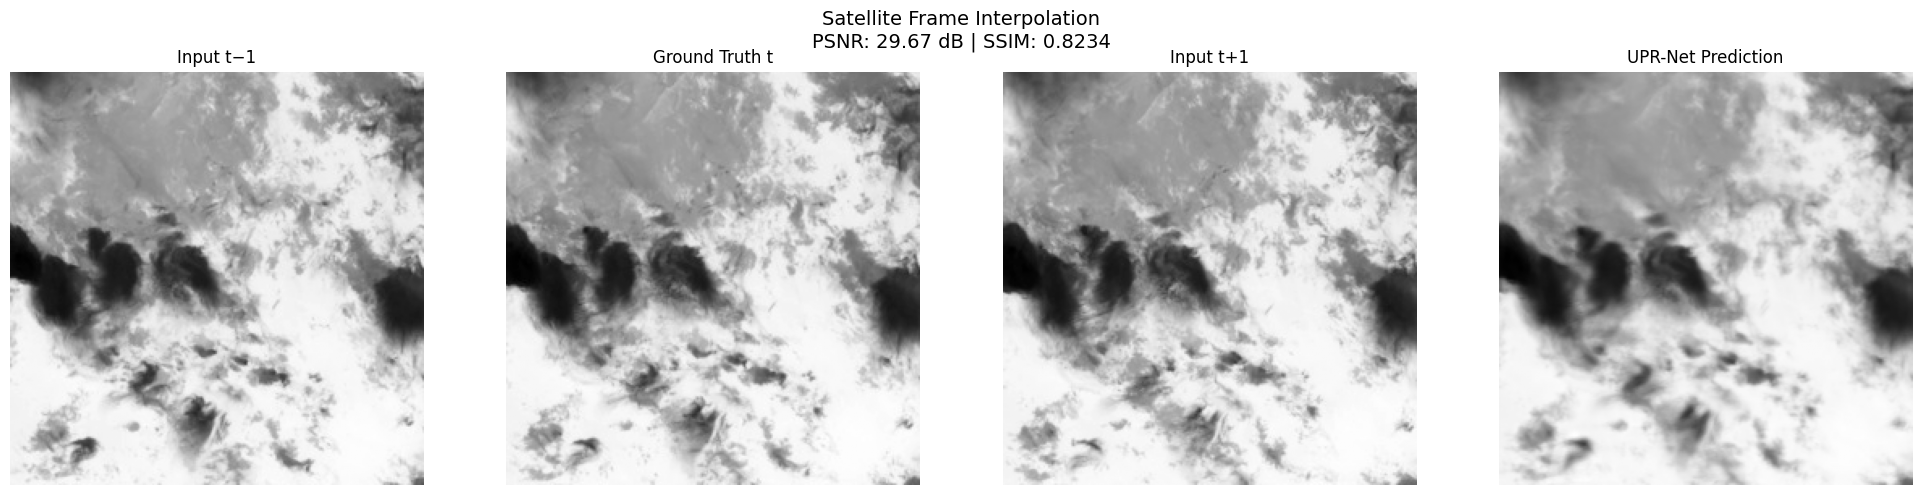

SAMPLE PREDICTION
PSNR : 29.6683 dB
SSIM : 0.823419


In [ ]:
# ============================================================
# VISUALIZE ONE TEST PREDICTION
# ============================================================

import torch
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 1. Get one test sample
# ------------------------------------------------------------

inputs, target = test_dataset[0]

# Add batch dimension
img0 = inputs[0:1].unsqueeze(0).to(device)
img1 = inputs[1:2].unsqueeze(0).to(device)
target_batch = target.unsqueeze(0).to(device)

# ------------------------------------------------------------
# 2. Generate prediction
# ------------------------------------------------------------

model.eval()

with torch.no_grad():

    prediction, bi_flow, extra = model(
        img0,
        img1,
        time_period=0.5
    )

prediction = torch.clamp(prediction, 0.0, 1.0)

# ------------------------------------------------------------
# 3. Convert to numpy
# ------------------------------------------------------------

img0_np = img0[0, 0].cpu().numpy()
img1_np = img1[0, 0].cpu().numpy()
target_np = target_batch[0, 0].cpu().numpy()
prediction_np = prediction[0, 0].cpu().numpy()

# ------------------------------------------------------------
# 4. Calculate sample metrics
# ------------------------------------------------------------

mse = np.mean((prediction_np - target_np) ** 2)

psnr = 10 * np.log10(1.0 / mse)

from skimage.metrics import structural_similarity

sample_ssim = structural_similarity(
    target_np,
    prediction_np,
    data_range=1.0
)

# ------------------------------------------------------------
# 5. Display
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img0_np, cmap="gray")
axes[0].set_title("Input t−1")
axes[0].axis("off")

axes[1].imshow(target_np, cmap="gray")
axes[1].set_title("Ground Truth t")
axes[1].axis("off")

axes[2].imshow(img1_np, cmap="gray")
axes[2].set_title("Input t+1")
axes[2].axis("off")

axes[3].imshow(prediction_np, cmap="gray")
axes[3].set_title("UPR-Net Prediction")
axes[3].axis("off")

plt.suptitle(
    f"Satellite Frame Interpolation\n"
    f"PSNR: {psnr:.2f} dB | SSIM: {sample_ssim:.4f}",
    fontsize=14
)

plt.tight_layout()
plt.show()

print("=" * 55)
print("SAMPLE PREDICTION")
print("=" * 55)
print(f"PSNR : {psnr:.4f} dB")
print(f"SSIM : {sample_ssim:.6f}")
print("=" * 55)

Input t-1 shape : (5424, 5424)
Ground truth    : (5424, 5424)
Input t+1 shape : (5424, 5424)
Patch size : 256 × 256
Stride     : 128
Y positions: 42
X positions: 42
Total patches: 1764


Full-resolution inference: 100%|██████████| 42/42 [00:34<00:00,  1.21it/s]



✅ Full-resolution prediction generated
Prediction shape: (5424, 5424)

       FULL-RESOLUTION RESULTS
Image size : 5424 × 5424
L1 Loss    : 0.010671
MSE        : 0.000562
PSNR       : 32.5019 dB
SSIM       : 0.905909


/tmp/ipykernel_726/1138610716.py:289: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(



✅ Saved:
/content/drive/MyDrive/UPRNet_Main_Training/fullres_prediction_2026-08-01_0002.jpg


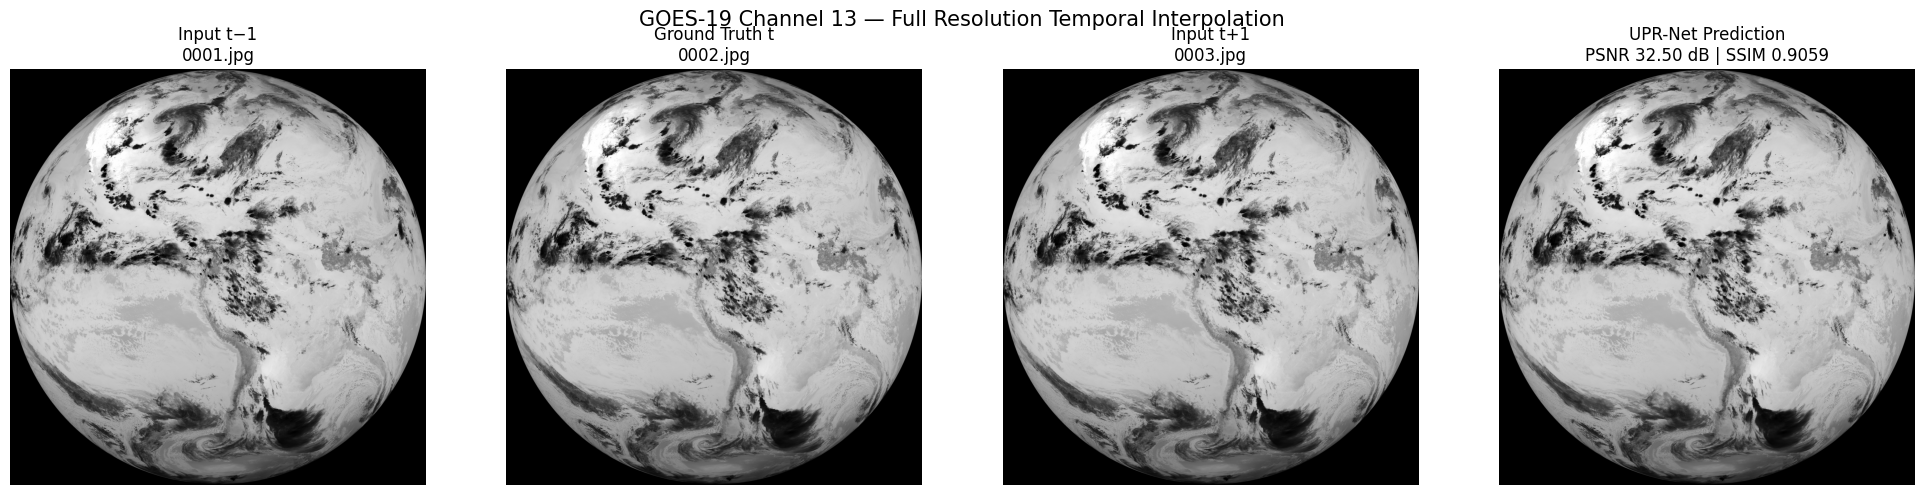

In [ ]:
# ============================================================
# FULL-RESOLUTION 5424x5424 INFERENCE
# Test sample: 2026-08-01
# Predict frame 0002 from frames 0001 and 0003
# ============================================================

import os
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

test_dir = "/content/drive/MyDrive/DATASETS_JPG/testing/2026-08-01"

img0_path = os.path.join(test_dir, "0001.jpg")   # t-1
gt_path   = os.path.join(test_dir, "0002.jpg")   # ground truth t
img1_path = os.path.join(test_dir, "0003.jpg")   # t+1

output_path = "/content/drive/MyDrive/UPRNet_Main_Training/fullres_prediction_2026-08-01_0002.jpg"

# ------------------------------------------------------------
# 2. Load full-resolution images
# ------------------------------------------------------------

img0_full = np.array(
    Image.open(img0_path).convert("L"),
    dtype=np.float32
) / 255.0

gt_full = np.array(
    Image.open(gt_path).convert("L"),
    dtype=np.float32
) / 255.0

img1_full = np.array(
    Image.open(img1_path).convert("L"),
    dtype=np.float32
) / 255.0

print("Input t-1 shape :", img0_full.shape)
print("Ground truth    :", gt_full.shape)
print("Input t+1 shape :", img1_full.shape)

assert img0_full.shape == (5424, 5424)
assert gt_full.shape == (5424, 5424)
assert img1_full.shape == (5424, 5424)

# ------------------------------------------------------------
# 3. Patch configuration
# ------------------------------------------------------------

PATCH = 256

# 50% overlap
STRIDE = 128

H, W = img0_full.shape

# Generate patch positions
ys = list(range(0, H - PATCH + 1, STRIDE))
xs = list(range(0, W - PATCH + 1, STRIDE))

# Make sure the final row/column reaches the image boundary
if ys[-1] != H - PATCH:
    ys.append(H - PATCH)

if xs[-1] != W - PATCH:
    xs.append(W - PATCH)

print(f"Patch size : {PATCH} × {PATCH}")
print(f"Stride     : {STRIDE}")
print(f"Y positions: {len(ys)}")
print(f"X positions: {len(xs)}")
print(f"Total patches: {len(ys) * len(xs)}")

# ------------------------------------------------------------
# 4. Output and weight accumulation arrays
# ------------------------------------------------------------

prediction_sum = np.zeros(
    (H, W),
    dtype=np.float32
)

weight_sum = np.zeros(
    (H, W),
    dtype=np.float32
)

# ------------------------------------------------------------
# 5. Use trained model
# ------------------------------------------------------------

model.eval()

# Process a few patches at a time
BATCH_SIZE = 4

patches0 = []
patches1 = []
locations = []

# ------------------------------------------------------------
# 6. Full-resolution inference
# ------------------------------------------------------------

with torch.no_grad():

    for y in tqdm(ys, desc="Full-resolution inference"):

        for x in xs:

            patch0 = img0_full[
                y:y+PATCH,
                x:x+PATCH
            ]

            patch1 = img1_full[
                y:y+PATCH,
                x:x+PATCH
            ]

            patches0.append(patch0)
            patches1.append(patch1)
            locations.append((y, x))

            # Process batch
            if len(patches0) == BATCH_SIZE:

                batch0 = torch.from_numpy(
                    np.stack(patches0)
                ).unsqueeze(1).to(
                    device,
                    non_blocking=True
                )

                batch1 = torch.from_numpy(
                    np.stack(patches1)
                ).unsqueeze(1).to(
                    device,
                    non_blocking=True
                )

                predictions, _, _ = model(
                    batch0,
                    batch1,
                    time_period=0.5
                )

                predictions = torch.clamp(
                    predictions,
                    0.0,
                    1.0
                )

                predictions = predictions[:, 0].cpu().numpy()

                # Accumulate predictions
                for pred, (py, px) in zip(
                    predictions,
                    locations
                ):

                    prediction_sum[
                        py:py+PATCH,
                        px:px+PATCH
                    ] += pred

                    weight_sum[
                        py:py+PATCH,
                        px:px+PATCH
                    ] += 1.0

                patches0 = []
                patches1 = []
                locations = []

    # --------------------------------------------------------
    # Process remaining patches
    # --------------------------------------------------------

    if len(patches0) > 0:

        batch0 = torch.from_numpy(
            np.stack(patches0)
        ).unsqueeze(1).to(device)

        batch1 = torch.from_numpy(
            np.stack(patches1)
        ).unsqueeze(1).to(device)

        predictions, _, _ = model(
            batch0,
            batch1,
            time_period=0.5
        )

        predictions = torch.clamp(
            predictions,
            0.0,
            1.0
        )

        predictions = predictions[:, 0].cpu().numpy()

        for pred, (py, px) in zip(
            predictions,
            locations
        ):

            prediction_sum[
                py:py+PATCH,
                px:px+PATCH
            ] += pred

            weight_sum[
                py:py+PATCH,
                px:px+PATCH
            ] += 1.0


# ------------------------------------------------------------
# 7. Blend overlapping patches
# ------------------------------------------------------------

prediction_full = prediction_sum / np.maximum(
    weight_sum,
    1e-8
)

prediction_full = np.clip(
    prediction_full,
    0.0,
    1.0
)

print("\n✅ Full-resolution prediction generated")
print("Prediction shape:", prediction_full.shape)

# ------------------------------------------------------------
# 8. Calculate full-resolution metrics
# ------------------------------------------------------------

from skimage.metrics import structural_similarity

mse_full = np.mean(
    (prediction_full - gt_full) ** 2
)

l1_full = np.mean(
    np.abs(prediction_full - gt_full)
)

psnr_full = 10 * np.log10(
    1.0 / mse_full
)

ssim_full = structural_similarity(
    gt_full,
    prediction_full,
    data_range=1.0
)

print("\n" + "=" * 60)
print("       FULL-RESOLUTION RESULTS")
print("=" * 60)

print(f"Image size : {H} × {W}")
print(f"L1 Loss    : {l1_full:.6f}")
print(f"MSE        : {mse_full:.6f}")
print(f"PSNR       : {psnr_full:.4f} dB")
print(f"SSIM       : {ssim_full:.6f}")

print("=" * 60)

# ------------------------------------------------------------
# 9. Save predicted 5424x5424 image
# ------------------------------------------------------------

prediction_uint8 = (
    prediction_full * 255.0
).round().astype(np.uint8)

Image.fromarray(
    prediction_uint8,
    mode="L"
).save(
    output_path,
    quality=95
)

print("\n✅ Saved:")
print(output_path)

# ------------------------------------------------------------
# 10. Visual comparison
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1, 4,
    figsize=(20, 5)
)

axes[0].imshow(
    img0_full,
    cmap="gray"
)
axes[0].set_title("Input t−1\n0001.jpg")
axes[0].axis("off")

axes[1].imshow(
    gt_full,
    cmap="gray"
)
axes[1].set_title("Ground Truth t\n0002.jpg")
axes[1].axis("off")

axes[2].imshow(
    img1_full,
    cmap="gray"
)
axes[2].set_title("Input t+1\n0003.jpg")
axes[2].axis("off")

axes[3].imshow(
    prediction_full,
    cmap="gray"
)
axes[3].set_title(
    f"UPR-Net Prediction\nPSNR {psnr_full:.2f} dB | SSIM {ssim_full:.4f}"
)
axes[3].axis("off")

plt.suptitle(
    "GOES-19 Channel 13 — Full Resolution Temporal Interpolation",
    fontsize=15
)

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files

files.download(
    "/content/drive/MyDrive/UPRNet_Main_Training/fullres_prediction_2026-08-01_0002.jpg"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# SAVE FINAL UPR-NET MODEL PERMANENTLY TO GOOGLE DRIVE
# ============================================================

import os
import shutil
import torch

# Make sure Drive is mounted
from google.colab import drive
drive.mount('/content/drive')

# Permanent project folder
project_dir = "/content/drive/MyDrive/UPRNet_Project"

os.makedirs(project_dir, exist_ok=True)

# Save final model
model_path = os.path.join(
    project_dir,
    "UPRNet_final.pth"
)

torch.save(
    model.state_dict(),
    model_path
)

print("✅ Model permanently saved!")
print(model_path)

# Check file size
size_mb = os.path.getsize(model_path) / (1024 ** 2)

print(f"Model size: {size_mb:.2f} MB")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model permanently saved!
/content/drive/MyDrive/UPRNet_Project/UPRNet_final.pth
Model size: 6.33 MB


In [ ]:
# ============================================================
# GOOGLE DRIVE STORAGE ANALYZER
# READ-ONLY — DOES NOT DELETE ANYTHING
# ============================================================

from google.colab import drive
import os

# Mount Google Drive
drive.mount("/content/drive")

DRIVE_ROOT = "/content/drive/MyDrive"

# ------------------------------------------------------------
# Scan files and calculate sizes
# ------------------------------------------------------------

file_info = []

print("🔍 Scanning your Google Drive...")
print("This may take some time if you have many files.\n")

for root, dirs, files in os.walk(DRIVE_ROOT):

    # Ignore some system/hidden folders
    dirs[:] = [
        d for d in dirs
        if not d.startswith(".")
    ]

    for filename in files:

        filepath = os.path.join(root, filename)

        try:
            size = os.path.getsize(filepath)

            relative_path = os.path.relpath(
                filepath,
                DRIVE_ROOT
            )

            file_info.append(
                (relative_path, size)
            )

        except (FileNotFoundError, PermissionError):
            pass


# ------------------------------------------------------------
# Sort largest files first
# ------------------------------------------------------------

file_info.sort(
    key=lambda x: x[1],
    reverse=True
)


# ------------------------------------------------------------
# Display top 50 largest files
# ------------------------------------------------------------

def format_size(size):

    if size >= 1024**3:
        return f"{size / 1024**3:.2f} GB"

    elif size >= 1024**2:
        return f"{size / 1024**2:.2f} MB"

    elif size >= 1024:
        return f"{size / 1024:.2f} KB"

    else:
        return f"{size} B"


print("=" * 80)
print("             TOP 50 LARGEST FILES")
print("=" * 80)

for i, (path, size) in enumerate(file_info[:50], 1):

    print(
        f"{i:2d}. {format_size(size):>12}   {path}"
    )


# ------------------------------------------------------------
# Total size scanned
# ------------------------------------------------------------

total_size = sum(
    size for _, size in file_info
)

print("\n" + "=" * 80)
print("DRIVE SCAN SUMMARY")
print("=" * 80)

print(f"Files scanned : {len(file_info):,}")
print(f"Total size    : {format_size(total_size)}")

print("\n✅ Scan complete.")
print("⚠️ No files were deleted.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔍 Scanning your Google Drive...
This may take some time if you have many files.

             TOP 50 LARGEST FILES
 1.      7.46 GB   Suhasini madam farewell /Madam talking about gifts and madam speech.mp4
 2.      6.90 GB   Suhasini madam farewell /Event Start.mp4
 3.      3.93 GB   Suhasini madam farewell /HOD  sir speech about Madams.mp4
 4.      3.00 GB   Product Trial.mp4
 5.      2.74 GB   Suhasini madam farewell /JD and Vamsi Speech Video.mp4
 6.      1.69 GB   Suhasini madam farewell /Madam Talking about gifts.mp4
 7.      1.69 GB   Suhasini madam farewell /Madam talking about gifts.mp4
 8.    796.36 MB   Suhasini madam farewell /Cake Cutting.mp4
 9.    790.95 MB   Suhasini madam farewell /Everyone coming onto the stage.mp4
10.    757.42 MB   Suhasini madam farewell /Madam Coming on to the stage for cake cutting.mp4
11.    543.95 MB   INTERVIEWS/Inter

In [ ]:
# ============================================================
# GOOGLE DRIVE — FOLDER STORAGE ANALYZER
# READ-ONLY — NOTHING WILL BE DELETED
# ============================================================

import os
from collections import defaultdict

DRIVE_ROOT = "/content/drive/MyDrive"

folder_sizes = defaultdict(int)

print("🔍 Calculating folder sizes...\n")

for root, dirs, files in os.walk(DRIVE_ROOT):

    dirs[:] = [
        d for d in dirs
        if not d.startswith(".")
    ]

    for filename in files:

        filepath = os.path.join(root, filename)

        try:
            size = os.path.getsize(filepath)

            # Top-level folder
            relative = os.path.relpath(
                filepath,
                DRIVE_ROOT
            )

            parts = relative.split(os.sep)

            if len(parts) > 1:
                top_folder = parts[0]
            else:
                top_folder = "[Files directly in My Drive]"

            folder_sizes[top_folder] += size

        except (FileNotFoundError, PermissionError):
            pass


def format_size(size):

    if size >= 1024**3:
        return f"{size / 1024**3:.2f} GB"

    elif size >= 1024**2:
        return f"{size / 1024**2:.2f} MB"

    elif size >= 1024:
        return f"{size / 1024:.2f} KB"

    return f"{size} B"


# Sort largest folders first
sorted_folders = sorted(
    folder_sizes.items(),
    key=lambda x: x[1],
    reverse=True
)

print("=" * 70)
print("              LARGEST DRIVE FOLDERS")
print("=" * 70)

for i, (folder, size) in enumerate(
    sorted_folders,
    1
):

    print(
        f"{i:3d}. {format_size(size):>12}   {folder}"
    )

print("=" * 70)

print("\n✅ Analysis complete.")
print("⚠️ Nothing was deleted.")

🔍 Calculating folder sizes...

              LARGEST DRIVE FOLDERS
  1.     27.69 GB   Suhasini madam farewell 
  2.     24.24 GB   DATASETS
  3.      7.23 GB   Colab Notebooks
  4.      6.87 GB   INTERVIEWS
  5.      5.66 GB   DATASETS_JPG
  6.      4.36 GB   Interviews
  7.      3.10 GB   [Files directly in My Drive]
  8.    556.26 MB   dataset
  9.    402.99 MB   UPRNet_Main_Training
 10.      6.33 MB   UPRNet_Project
 11.      5.77 MB   DATASETS_JPG_TEST
 12.    144.67 KB   Google AI Studio

✅ Analysis complete.
⚠️ Nothing was deleted.


In [ ]:
# ============================================================
# INSPECT SUHASINI MADAM FAREWELL FOLDER
# READ-ONLY — NOTHING WILL BE DELETED
# ============================================================

import os

folder = "/content/drive/MyDrive/Suhasini madam farewell"

files = []

for root, dirs, filenames in os.walk(folder):

    for filename in filenames:

        filepath = os.path.join(root, filename)

        try:
            size = os.path.getsize(filepath)
            files.append((filepath, size))
        except:
            pass


files.sort(key=lambda x: x[1], reverse=True)


def format_size(size):

    if size >= 1024**3:
        return f"{size / 1024**3:.2f} GB"
    elif size >= 1024**2:
        return f"{size / 1024**2:.2f} MB"
    else:
        return f"{size / 1024:.2f} KB"


print("=" * 90)
print("        SUHASINI MADAM FAREWELL — FILES BY SIZE")
print("=" * 90)

total = 0

for i, (filepath, size) in enumerate(files, 1):

    relative = os.path.relpath(filepath, folder)

    print(
        f"{i:3d}. {format_size(size):>12}   {relative}"
    )

    total += size


print("=" * 90)
print(f"Files: {len(files)}")
print(f"Total: {format_size(total)}")
print("=" * 90)

print("\n⚠️ NOTHING WAS DELETED.")

        SUHASINI MADAM FAREWELL — FILES BY SIZE
Files: 0
Total: 0.00 KB

⚠️ NOTHING WAS DELETED.


In [ ]:
import os

DRIVE_ROOT = "/content/drive/MyDrive"

print("Folders in My Drive containing 'Suhasini':\n")

for name in os.listdir(DRIVE_ROOT):
    if "Suhasini" in name:
        full_path = os.path.join(DRIVE_ROOT, name)

        print(f"Name      : {repr(name)}")
        print(f"Path      : {repr(full_path)}")
        print(f"Is folder : {os.path.isdir(full_path)}")
        print("-" * 60)

Folders in My Drive containing 'Suhasini':

Name      : 'Suhasini madam farewell '
Path      : '/content/drive/MyDrive/Suhasini madam farewell '
Is folder : True
------------------------------------------------------------
Name      : 'Suhasini madam retirement'
Path      : '/content/drive/MyDrive/Suhasini madam retirement'
Is folder : True
------------------------------------------------------------


In [ ]:
# ============================================================
# INSPECT SUHASINI MADAM FAREWELL FOLDER
# CORRECT PATH INCLUDING TRAILING SPACE
# READ-ONLY
# ============================================================

import os

folder = "/content/drive/MyDrive/Suhasini madam farewell "

files = []

for root, dirs, filenames in os.walk(folder):

    for filename in filenames:

        filepath = os.path.join(root, filename)

        try:
            size = os.path.getsize(filepath)
            files.append((filepath, size))
        except (FileNotFoundError, PermissionError):
            pass


files.sort(key=lambda x: x[1], reverse=True)


def format_size(size):
    if size >= 1024**3:
        return f"{size / 1024**3:.2f} GB"
    elif size >= 1024**2:
        return f"{size / 1024**2:.2f} MB"
    elif size >= 1024:
        return f"{size / 1024:.2f} KB"
    else:
        return f"{size} B"


print("=" * 90)
print("     SUHASINI MADAM FAREWELL — FILES BY SIZE")
print("=" * 90)

total = 0

for i, (filepath, size) in enumerate(files, 1):

    relative = os.path.relpath(filepath, folder)

    print(
        f"{i:3d}. {format_size(size):>12}   {relative}"
    )

    total += size


print("=" * 90)
print(f"Files : {len(files)}")
print(f"Total : {format_size(total)}")
print("=" * 90)

print("\n⚠️ NOTHING WAS DELETED.")

     SUHASINI MADAM FAREWELL — FILES BY SIZE
  1.      7.46 GB   Madam talking about gifts and madam speech.mp4
  2.      6.90 GB   Event Start.mp4
  3.      3.93 GB   HOD  sir speech about Madams.mp4
  4.      2.74 GB   JD and Vamsi Speech Video.mp4
  5.      1.69 GB   Madam Talking about gifts.mp4
  6.      1.69 GB   Madam talking about gifts.mp4
  7.    796.36 MB   Cake Cutting.mp4
  8.    790.95 MB   Everyone coming onto the stage.mp4
  9.    757.42 MB   Madam Coming on to the stage for cake cutting.mp4
 10.    479.82 MB   Madam Felicitation.mp4
 11.    393.80 MB   Madam reaction to AV.mp4
 12.      2.20 MB   IMG_20260831_134113.jpg
 13.      2.16 MB   IMG_20260831_134125.jpg
 14.      2.14 MB   IMG_20260831_133529.jpg
 15.      2.14 MB   IMG_20260831_133524.jpg
 16.      2.13 MB   IMG_20260831_133556.jpg
 17.      2.13 MB   IMG_20260831_133525.jpg
 18.      2.13 MB   IMG_20260831_133619.jpg
 19.      2.13 MB   IMG_20260831_134259.jpg
 20.      2.13 MB   IMG_20260831_133611.jpg
 21

In [ ]:
# ============================================================
# FIND EXACT DUPLICATE VIDEOS
# READ-ONLY — NOTHING WILL BE DELETED
# ============================================================

import os
import hashlib
from collections import defaultdict

folder = "/content/drive/MyDrive/Suhasini madam farewell "

video_extensions = {
    ".mp4", ".mkv", ".avi", ".mov", ".wmv", ".m4v"
}

video_files = []

for root, dirs, files in os.walk(folder):

    for filename in files:

        ext = os.path.splitext(filename)[1].lower()

        if ext in video_extensions:

            filepath = os.path.join(root, filename)

            try:
                size = os.path.getsize(filepath)

                video_files.append(
                    (filepath, size)
                )

            except:
                pass


def get_hash(filepath, chunk_size=8 * 1024 * 1024):

    sha256 = hashlib.sha256()

    with open(filepath, "rb") as f:

        while True:

            chunk = f.read(chunk_size)

            if not chunk:
                break

            sha256.update(chunk)

    return sha256.hexdigest()


print(f"Found {len(video_files)} video files.")
print("Calculating hashes... This may take a while because the videos are large.\n")

hash_groups = defaultdict(list)

for i, (filepath, size) in enumerate(video_files, 1):

    print(
        f"\rProcessing {i}/{len(video_files)}",
        end=""
    )

    file_hash = get_hash(filepath)

    hash_groups[file_hash].append(
        (filepath, size)
    )

print("\n\n" + "=" * 80)
print("                EXACT DUPLICATES")
print("=" * 80)

duplicate_groups = []

for file_hash, group in hash_groups.items():

    if len(group) > 1:

        duplicate_groups.append(group)


if not duplicate_groups:

    print("No exact duplicate videos found.")

else:

    total_recoverable = 0

    for i, group in enumerate(
        duplicate_groups,
        1
    ):

        print(f"\nDuplicate Group {i}:")

        for filepath, size in group:

            print(
                f"  {size / 1024**3:.2f} GB  "
                f"{os.path.basename(filepath)}"
            )

        # Keep one copy, other copies are potentially removable
        recoverable = sum(
            size for _, size in group[1:]
        )

        total_recoverable += recoverable

    print("\n" + "=" * 80)

    print(
        f"Potential space from exact duplicates: "
        f"{total_recoverable / 1024**3:.2f} GB"
    )

print("=" * 80)
print("\n⚠️ NOTHING WAS DELETED.")

Found 11 video files.
Calculating hashes... This may take a while because the videos are large.

Processing 11/11

                EXACT DUPLICATES

Duplicate Group 1:
  1.69 GB  Madam Talking about gifts.mp4
  1.69 GB  Madam talking about gifts.mp4

Potential space from exact duplicates: 1.69 GB

⚠️ NOTHING WAS DELETED.
